In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from obspy import read, read_events, Stream
from obspy.signal.trigger import classic_sta_lta
from obspy.geodetics import gps2dist_azimuth, kilometer2degrees
from obspy.taup import TauPyModel, taup_create
from collections import defaultdict

In [2]:
# Path to directory containing processed SAC files
data_dir = "data/sac_files"   
catfile = 'data/aec_events.xml'

sac_files = sorted(glob.glob(os.path.join(data_dir, "*.sac")))

print(f"Found {len(sac_files)} SAC files")

Found 302 SAC files


In [3]:
stream = Stream()

for file in sac_files:
    stream += read(file)

aec_catalog = read_events(catfile)
event = aec_catalog[0]
event_depth = event.origins[0].depth/1000

In [4]:
streamZ = stream.select(component="Z")

for tr in stream:
    stla = tr.stats.sac.stla
    stlo = tr.stats.sac.stlo
    evla = tr.stats.sac.evla
    evlo = tr.stats.sac.evlo

    dist_m, az, baz = gps2dist_azimuth(evla, evlo, stla, stlo)
    tr.stats.distance = dist_m  # in meters

In [5]:
# Set plot limits
minoff = 95e03
maxoff = 350e03
timeStart = 0
timeLength = 300

Building obspy.taup model for 'data/brocher2004.tvel' ...
filename = data/brocher2004.tvel
Done reading velocity model.
Radius of model  is 6371.0
Using parameters provided in TauP_config.ini (or defaults if not) to call SlownessModel...
Parameters are:
taup.create.min_delta_p = 0.1 sec / radian
taup.create.max_delta_p = 11.0 sec / radian
taup.create.max_depth_interval = 115.0 kilometers
taup.create.max_range_interval = 0.04363323129985824 degrees
taup.create.max_interp_error = 0.05 seconds
taup.create.allow_inner_core_s = True
Slow model  911 P layers,1133 S layers
Done calculating Tau branches.
Done Saving /import/home/irseppi/.conda/envs/denalinodal/lib/python3.9/site-packages/obspy/taup/data/brocher2004.npz
Method run is done, but not necessarily successful.


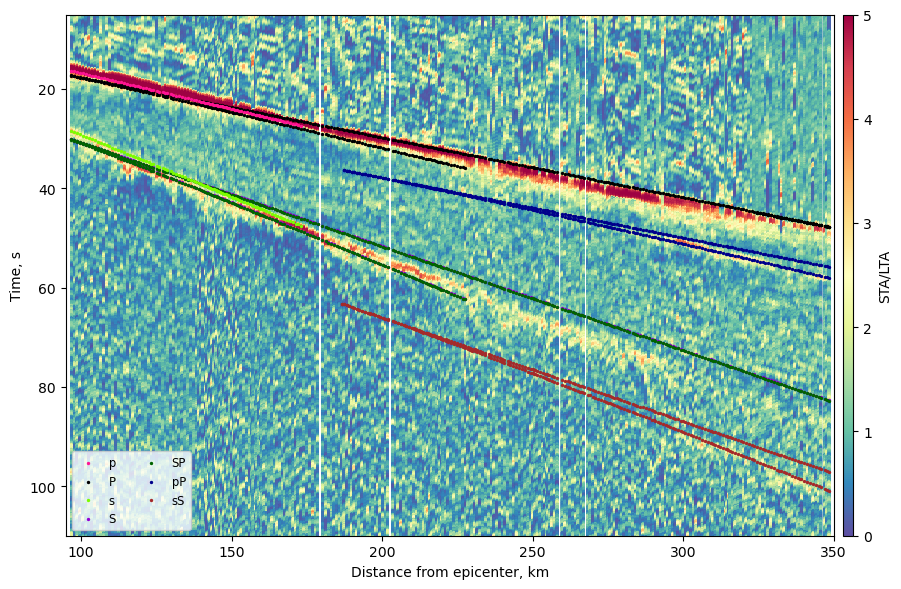

In [6]:
# Build per-phase arrival dictionary and plot with unique colors + STA/LTA background
phase_dict = defaultdict(list)

taup_create.build_taup_model("data/brocher2004.tvel")
model = TauPyModel(model="brocher2004")

phase_dict = defaultdict(list)

plt.figure(figsize=(10, 6))

# Plot STA/LTA background
for tr in streamZ.select(channel="DPZ"):
    df = tr.stats.sampling_rate
    sta = int(1 * df)
    lta = int(5 * df)

    sta_lta = classic_sta_lta(tr.data, sta, lta)

    dist_km = tr.stats.distance / 1e3
    timelist = np.arange(tr.stats.npts) / df

    cax = plt.scatter(
        np.full(tr.stats.npts, dist_km), timelist,
        c=sta_lta,
        s=0.7,
        cmap="Spectral_r",
        vmin=0, vmax=5,
        rasterized=True,
        zorder=0
    )

    # get arrivals and accumulate by phase name
    arrival_s = model.get_travel_times(source_depth_in_km=event_depth,
                                       distance_in_degree=kilometer2degrees(dist_km), 
                                       phase_list=["P","p", "S", "pP", "sS", "pS", "SP","s"])
    for a in arrival_s:
        phase_dict[a.name].append((dist_km, a.time))

phases = sorted(phase_dict.keys(), key=lambda p: min(t for (_, t) in phase_dict[p]))

colors = ['deeppink','black','lawngreen', 'darkviolet','darkgreen','darkblue','brown']

# Plot arrivals per phase with legend entries
for i, phase in enumerate(phases):
    pts = phase_dict[phase]
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    if phase == "p" or phase == "s":
        plt.scatter(xs, ys, color=colors[i], label=phase, zorder=1000,s=2)
    else:
        plt.scatter(xs, ys, color=colors[i], label=phase, zorder=100,s=2)
plt.xlabel("Distance from epicenter, km")
plt.ylabel("Time, s")
plt.xlim(minoff / 1e3, maxoff / 1e3)
plt.ylim(timeStart + 5, timeStart + 110)
plt.gca().invert_yaxis()
plt.colorbar(cax, label="STA/LTA", pad=0.01, aspect=50)
plt.legend(loc='lower left', fontsize='small', ncol=2)
plt.tight_layout()
plt.savefig(f'event1_DPZ_staLta_phases.png', dpi=200)
